In [1]:
!date

Wed Sep 16 20:10:57 PDT 2026


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'

In [3]:
### chr20, 500bp bins, hg38-anchored (lifted from each donor's own hap1/hap2 native-assembly
### methcounts via existing chain files, hap1+hap2 combined by coverage-weighted mean per donor).
### 32 donors have methcounts as of this run (job 14771403 still generating the rest of the
### 202-donor cohort) -- bins kept only if >=19 donors (60% of available) each have >=20 total
### read/call coverage, to avoid noisy per-bin variance estimates from sparse donors.
df = pd.read_csv(f'{projdir}/results/qc/data/variance_decomp/chr20_bin_variance.tsv', sep='\t')

In [4]:
df.head()

,bin_start,n_donors,mean_meth,var_meth,sd_meth,is_cpgi,is_gene
0,60000,32,0.327775,0.008789,0.093752,0,0
1,60500,32,0.601479,0.003734,0.061103,0,0
2,61000,32,0.783083,0.002404,0.049026,0,0
3,61500,32,0.609214,0.004422,0.066496,0,0
4,62000,32,0.382850,0.009459,0.097259,0,0


In [5]:
df.shape

(117068, 7)

In [6]:
### stratified comparison -- mean/median cross-donor SD by annotation category
df.groupby(['is_cpgi','is_gene'])['sd_meth'].agg(['count','mean','median'])

count      mean    median
is_cpgi is_gene                           
0       0        46788  0.071310  0.070281
        1        68189  0.060983  0.059772
1       0          345  0.060166  0.052772
        1         1746  0.051137  0.047977

In [7]:
### linear model: does CpG-island / gene-body membership predict a bin's cross-donor SD?
m = smf.ols('sd_meth ~ is_cpgi + is_gene', data=df).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                sd_meth   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2120.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:11:06   Log-Likelihood:             2.5280e+05
No. Observations:              117068   AIC:                        -5.056e+05
Df Residuals:                  117065   BIC:                        -5.056e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0713      0.000    554.065      0.0

In [8]:
### effect sizes relative to the intergenic/non-CpGI baseline
baseline = df[(df['is_cpgi']==0)&(df['is_gene']==0)]['sd_meth'].mean()
for cpgi, gene, label in [(0,0,'intergenic, non-CpGI'), (0,1,'gene body, non-CpGI'),
                          (1,0,'CpG island, non-genic'), (1,1,'CpG island + gene body (promoter CGI)')]:
    sub = df[(df['is_cpgi']==cpgi)&(df['is_gene']==gene)]['sd_meth'].mean()
    print(f'{label}: mean SD={sub:.4f}  ({100*(sub-baseline)/baseline:+.1f}% vs baseline)')

intergenic, non-CpGI: mean SD=0.0713  (+0.0% vs baseline)
gene body, non-CpGI: mean SD=0.0610  (-14.5% vs baseline)
CpG island, non-genic: mean SD=0.0602  (-15.6% vs baseline)
CpG island + gene body (promoter CGI): mean SD=0.0511  (-28.3% vs baseline)


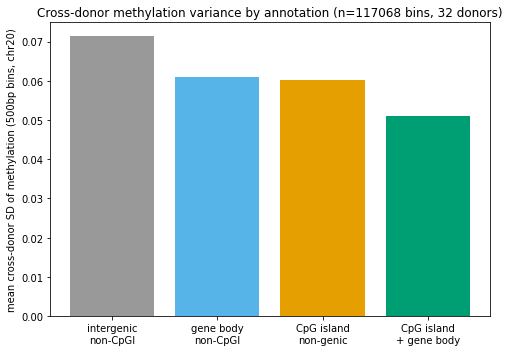

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
cats = ['intergenic\nnon-CpGI', 'gene body\nnon-CpGI', 'CpG island\nnon-genic', 'CpG island\n+ gene body']
means = [df[(df['is_cpgi']==c)&(df['is_gene']==g)]['sd_meth'].mean() for c,g in [(0,0),(0,1),(1,0),(1,1)]]
ax.bar(cats, means, color=['#999999','#56B4E9','#E69F00','#009E73'])
ax.set_ylabel('mean cross-donor SD of methylation (500bp bins, chr20)')
ax.set_title(f'Cross-donor methylation variance by annotation (n={df.shape[0]} bins, 32 donors)')
plt.tight_layout()

In [10]:
outdir = f'{projdir}/results/qc/figures'
import os
os.makedirs(outdir, exist_ok=True)
fig.savefig(f'{outdir}/qc11_variance_by_annotation.png', dpi=150, bbox_inches='tight')

In [11]:
### PMD annotation NOT included here -- no donor in this 32-donor set has a real dnmtools PMD
### call yet (job 14771405 is held on the full 202-donor methcounts array, 14771403, finishing
### first). The three donors with real PMD calls (NA19338/HG01981/HG04187, from this session's
### earlier pilot validation) are not in this 32-donor set -- once the full array lands, rerun
### this notebook adding a per-bin "fraction of donors with a PMD call overlapping this bin"
### covariate to the model above.

In [12]:
!date

Wed Sep 16 20:11:08 PDT 2026
